<a href="https://colab.research.google.com/github/VioletLiu0620/deeplearning/blob/main/notes/03_pytorch_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pytorch Computer Vision

## 0. Computer vision libraries in PyTorch

https://docs.pytorch.org/vision/stable/index.html

- `torchvision.datasets` - get datasets and data loading functions for computer vision
- `torchvision.models` - get pretrained computer vision models that you can leverage for your own problem
- `torchvision.transforms` - functions for manipulating your vision data (images) to be suitable for use with an ML model - turn our image to data that we can use
- `torch.utils.data.Dataset` - Base dataset class for PyTorch.
- `torch.utils.data.DataLoader` - creates a python iterable over a dataset

In [ ]:
# Import Pytorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Import matplotlib
import matplotlib.pyplot as plt

# check versions
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


## 1. Getting a dataset

The dataset we'll be using FasionMNIST from torchvision.datasets

In [ ]:
from torch.utils.data import dataset
# Setup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # do we want the training dataset?
    download=True, # Do we want to download? yes/no
    transform= torchvision.transforms.ToTensor(), # how do we want to transform the data
    target_transform=None#  how do we want to transofrm the labels/targets
)

test_data = datasets.FashionMNIST(
    root="data",
    train= False,
    download = True,
    transform=ToTensor(),
    target_transform= None
)

In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
# See the first training example
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
class_name = train_data.classes
class_name

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [ ]:
# Check the shape of our image
image.shape, label, class_name[label]

# CxHxW, pytorch has color channel in front
# all the pictures are grey scale, so only one channel

(torch.Size([1, 28, 28]), 9, 'Ankle boot')

### 1.2 Visualizng our data

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

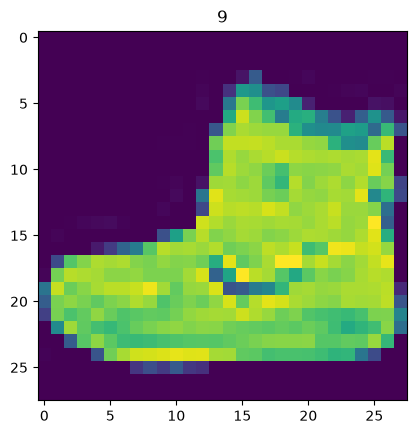

In [ ]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

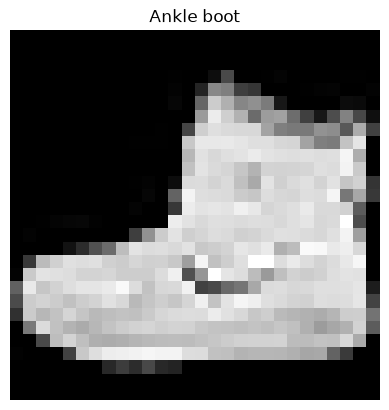

In [ ]:
plt.imshow(image.squeeze(), cmap="grey")
plt.title(class_name[label])
plt.axis(False)

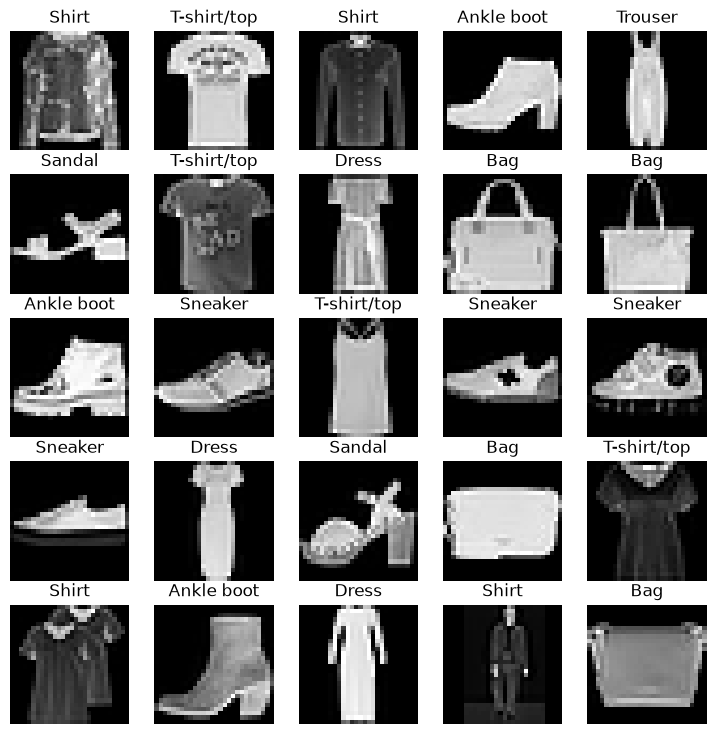

In [ ]:
# plot more images
fig = plt.figure(figsize=(9,9))
rows, cols = 5, 5
for i in range(1, rows*cols+1):
  random_idx = torch.randint(0, len(train_data), size =[1]).item()
  image, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(image.squeeze(), cmap = "grey")
  plt.title(class_name[label])
  plt.axis(False)

Do you think these items of clothing images could be modelled with pure linear lines or do you think we'll need non-linearities?

## 2. Prepare Dataloader

Right now, our data is in the form of PyTorch datasets.

Dataloader turns our dataset into a python iterable

More specifically, we want to turn our data into batches (or mini-batches).

Why would we do this?

1. It is more computationaly efiicient,as in, your computing hardware may not be able to look (store in memory) at 60000 images in one hit. So we break it down ot 32 image at a time (batch size of 32).

2. It gives our neural networks more chances to updata its gradient per epoch.

In [ ]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into python interables
train_dataloader = DataLoader(dataset=train_data,
                              batch_size= BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                              batch_size= BATCH_SIZE,
                              shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7904f7c74110>,
 <torch.utils.data.dataloader.DataLoader at 0x7904f7a67bc0>)

In [ ]:
# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of the train_dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7904f7c74110>, <torch.utils.data.dataloader.DataLoader object at 0x7904f7a67bc0>)
Length of the train_dataloader: 1875 batches of 32


In [ ]:
# Check out what's inside the training data loader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

torch.Size([1, 28, 28])


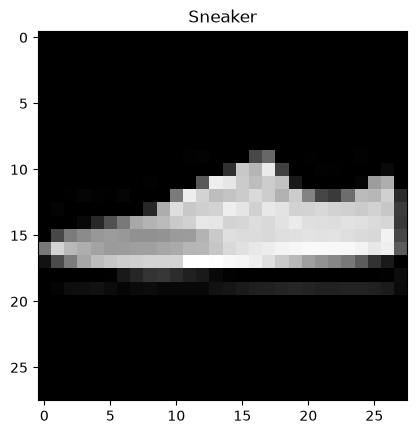

In [ ]:
# Show a sample

random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
image, label = train_features_batch[random_idx], train_labels_batch[random_idx]

plt.imshow(image.squeeze(), cmap="grey")
plt.axis
plt.title(class_name[label])
print(image.shape)

## 3. Model 0: build a baseline model

When starting to build a series of machine learning modelling experiments, it's best practice to start with a baseline model.

A baseline model is a simple model you will try and improve upon with subsequent models/experiments.

In other words, start simply and add complexity later on.

In [ ]:
# Create a flatten layer
flatten_model = nn.Flatten(
)

# get a simgle sample
x = train_features_batch[0]

# flatten the sample
output = flatten_model(x) # perform forward pass

# print out what happend
print(f"shape before flattening: {x.shape} -> color, height, width")
print(f"shape after flattening: {output.shape} -> color, height*width")

shape before flattening: torch.Size([1, 28, 28]) -> color, height, width
shape after flattening: torch.Size([1, 784]) -> color, height*width


In [ ]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= input_shape,
                  out_features= hidden_units),
        nn.Linear(in_features= hidden_units,
                  out_features= output_shape)
    )
  def forward(self, x):
    return self.layer_stack(x)


In [ ]:
torch.manual_seed(42)

# Setup model with input parameters
model_0 = FashionMNISTModelV0(
    input_shape = 28*28, # height*width = 784
    hidden_units= 10,
    output_shape= len(class_name) # one for every class = 10
).to("cpu")
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
dummy_x = torch.rand([1, 1, 28, 28])
model_0(dummy_x).shape

torch.Size([1, 10])

### 3.1 Setup loss, optimizer and evaluation metrics

* Loss function - since we're working with multi-class data, our loss function will be `nn.CrossEntropyLoss()`
* Optimizer - our optimizer`torch.optim.SGD()` (stochastic gradient descent)
* Evaluation metric - since we're working on a classficiation metrics, let's use accuracy as evaluation metric

In [ ]:
import requests
from pathlib import Path

# download helper functions from learn pytorch repo
if Path("helper_functions.py").is_file():
  print("already exist")
else:
  print("downloading")
  request= requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

already exist


In [ ]:
# Import accuracy metric
from helper_functions import accuracy_fn

# Setup loss fucntion and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params= model_0.parameters(),
                            lr= 0.1)

### 3.2 Creating a fucntion to time our experiement

Machine learning is very experimental.

Two of the main thing you'll often want to track are:

1. Model's performance (loss and accuracy values etc)
2. How fast it runs

In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  """
  Print difference between start and end time.
  """
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [ ]:
start_time = timer()
for i in range(20):
  print(i) if i % 5 == 0 else next
end_time = timer()
print_train_time(start_time, end=end_time, device = "cpu")

0
5
10
15
Train time on cpu: 0.000 seconds


0.00020508800025709206

### 3.3 Creating a training loop and training a mdoel on batches of data

1. Loop through epochs.
2. Loop through training batches, perform training steps, calculate the train loss *per batch*
3. Loop through testing batches, perform testing steps, calculate the test loss *per batch*.
4. Print out what's happening
5. Time it all

In [ ]:
# Import tgdm progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs (we'll keep this small for faster training time)
epochs = 3

# Create training and test loop
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------------")

  ### Training
  train_loss = 0

  # Add a loop to loop through the training batches
  for batch, (X, y) in enumerate(train_dataloader): # enumerate give ouput in (number, item) format
    model_0.train()
    # 1. Forward pass
    y_pred = model_0(X)

    # 2. Calculate loss (per batch)
    loss = loss_fn(y_pred, y)
    train_loss += loss # accumulate train loss

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

  # Print out what's happening
    if batch % 400 == 0:
      print(f"Looked at {batch*len(X)}/{len(train_dataloader.dataset)} samples")

  # Divide total train loss by length of train dataloader
  train_loss /= len(train_dataloader)

  ### Testing
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      # 1. Forward pass
      test_pred = model_0(X_test)

      # 2. Calculate loss
      test_loss += loss_fn(test_pred,y_test)

      # 3. Calculate accuracy
      test_acc += accuracy_fn(y_true=y_test,
                              y_pred=test_pred.argmax(dim=1))

    # Calculate the test loss average per batch
    test_loss /= len(test_dataloader)

    # Calculaet the test acc average per batch
    test_acc /= len(test_dataloader)

  # Print out what's happening
  print(f"Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test acc: {test_acc:.4f}\n")

# Calculate teh training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start= train_time_start_on_cpu,
                                            end = train_time_end_on_cpu,
                                            device= str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss: 0.5904, Test Loss: 0.5095, Test acc: 82.0387

Epoch: 1
-------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss: 0.4763, Test Loss: 0.4799, Test acc: 83.1969

Epoch: 2
-------------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss: 0.4550, Test Loss: 0.4766, Test acc: 83.4265

Train time on cpu: 40.723 seconds


In [ ]:
next(model_0.parameters()).device

device(type='cpu')

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## 4. Make prediction and get Model 0 results

In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device= device):
  """Returns a dictionary containing the results of model predicting on data_loader."""
  loss, acc = 0, 0

  model.eval()

  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # Make predictions
      y_pred = model(X)

      # Accumulate the loss and acc values per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y,
                         y_pred=y_pred.argmax(dim=1))

    # Scale the loss and acc to find the average loss / acc per batch
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__, # only works when model was created with class
          "model_loss": loss.item(),
          "model_accuracy": acc}


In [ ]:
model_0.to(device)
next(model_0.parameters()).device


device(type='cuda', index=0)

In [ ]:
# Calculate model 0 result
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn = loss_fn,
                             accuracy_fn= accuracy_fn)
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.4766389727592468,
 'model_accuracy': 83.42651757188499}

## 5. Setup device agnostic-code

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 6. Model 1: Building a better model with non-linearity

In [ ]:
# Create a model with non-linear and linear layer

class FashionMNISTModelV1(nn.Module):
  def __init__(self,
               input_shape: int,
               output_shape: int,
               hidden_units: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= input_shape,
                  out_features= hidden_units),
        nn.ReLU(),
        nn.Linear(in_features= hidden_units,
                  out_features= output_shape),
    )
  def forward(self, x:torch.Tensor):
    return self.layer_stack(x)

In [ ]:
device

'cuda'

In [ ]:
# Create an instance of model 1
torch.manual_seed(42)
model_1 = FashionMNISTModelV1(input_shape= 28*28,
                              hidden_units= 10,
                              output_shape= 10).to(device)

In [ ]:
next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.1 Setup loss, optimizer and evaluation metrics

In [ ]:
# Loss and optimizer
loss_fn = nn.CrossEntropyLoss() # measure how wrong our model is
optimizer = torch.optim.SGD(params=model_1.parameters(), # tries to update our model parameter to reduce the loss
                            lr=0.1)

from helper_functions import accuracy_fn

### 6.2 Functionizing training and evaluation/testing loops

- training loop - `train_step()`
- testing loop - `test_step()`

In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
  # Performs a training with model trying to learn on data_loader.
  train_loss = 0
  train_acc = 0

  # Put model into training mode
  model.train()

  for batch, (X, y) in enumerate(data_loader): # enumerate give ouput in (number, item) format
    # Put data on target deivce
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)

    # 2. Calculate loss and acc(per batch)
    loss = loss_fn(y_pred, y)
    train_loss += loss # accumulate train loss
    train_acc += accuracy_fn(y_true= y,
                             y_pred=y_pred.argmax(dim=1))

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

  # Divide the total train loss and acc by length of train dataloader
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train Loss: {train_loss:.4f}, Train acc: {train_acc:.4f}\n")

In [ ]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              optimizer: torch.optim.Optimizer,
              accuracy_fn,
              device: torch.device = device):

  test_loss, test_acc = 0, 0

  # Put model on evaluation mode
  model.eval()

  with torch.inference_mode():
    for X_test, y_test in data_loader:
      # Send data to the target device
      X_test, y_test = X_test.to(device), y_test.to(device)

      # 1. Forward pass
      test_pred = model(X_test)

      # 2. Calculate loss and acc
      test_loss += loss_fn(test_pred,y_test)

      # 3. Calculate accuracy
      test_acc += accuracy_fn(y_true=y_test,
                              y_pred=test_pred.argmax(dim=1))

    # Calculate the test loss average per batch
    test_loss /= len(data_loader)

    # Calculaet the test acc average per batch
    test_acc /= len(data_loader)

    print(f"Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}\n")

In [ ]:
torch.manual_seed(42)

epochs = 3

# Measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}")

  train_step(model=model_1,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)

  test_step(model=model_1,
             data_loader=test_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)

train_time_end_on_gpu = timer()
total__train_time_model_1 = print_train_time(start= train_time_start_on_gpu,
                                             end= train_time_end_on_gpu,
                                             device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
Train Loss: 0.6461, Train acc: 77.1700

Test loss: 0.5386, Test acc: 80.7608

Epoch: 1
Train Loss: 0.4809, Train acc: 82.9433

Test loss: 0.4939, Test acc: 82.4581

Epoch: 2
Train Loss: 0.4469, Train acc: 84.1633

Test loss: 0.4575, Test acc: 83.9856

Train time on cuda: 37.692 seconds


In [ ]:
model_1_results = eval_model(model= model_1,
                             data_loader= test_dataloader,
                             loss_fn= loss_fn,
                             accuracy_fn= accuracy_fn,
                             device= device)
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.45746350288391113,
 'model_accuracy': 83.98562300319489}

## Model 2: Building a Convolutional Neural Network (CNN)

CNN's are also know ConvNets.

CNN's are know for their capabilities to find patterns in visual data.

To find out waht's happening inside a CNN, see this https://poloclub.github.io/cnn-explainer/#article-convolution

In [ ]:
# Create a convolutional neural network
class FashionMINSTModelV2(nn.Module):
  """
  Model architecture that replicates the TinyVGG
  model from CNN explainer website.
  """
  def __init__(self,
                input_shape: int,
                hidden_units: int,
                output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        # Create a con layer
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1), # values we can set ourselves in our NN's are called hyperparameters
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1, # how you move the kernel, should be at least one, how many space block there should be when kernal outputing the output
                  padding=1), # can be 0 or 1, adding zero on the edges
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(), # flatten ignore the first dim, and mutiply everything behind together for it to be a 1xA vector, for A be (a*b*c*d....) if before it is 1xaxbxcxd
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    # print(x.shape)
    x = self.conv_block_2(x)
    # print(x.shape)
    x = self.classifier(x)
    # print(x.shape)
    return x


In [ ]:
torch.manual_seed(42)
model_2 = FashionMINSTModelV2(input_shape=1,
                              hidden_units=10,
                              output_shape= len(class_name)).to(device)

In [ ]:
next(model_2.parameters()).device
len(class_name)

10

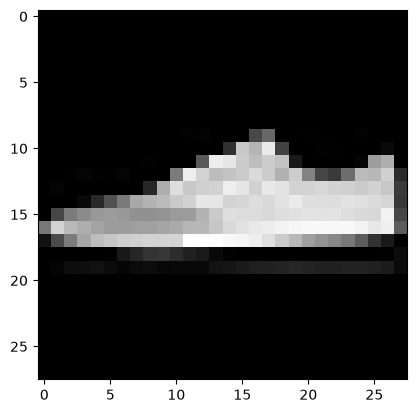

In [ ]:
plt.imshow(image.squeeze(), cmap="grey")

In [ ]:
image = image.to(device)
image.shape

torch.Size([1, 28, 28])

In [ ]:
model_2(image.unsqueeze(dim=0))

tensor([[ 0.0306, -0.0610,  0.0522, -0.0263, -0.0175,  0.0178, -0.0054, -0.0048,
          0.0249,  0.0098]], device='cuda:0', grad_fn=<AddmmBackward0>)

### 7. 1 Steping through `nn.Conv2d()`

In [ ]:
torch.manual_seed(42)

# Create a batch of image
images = torch.randn(size=(32, 3, 64, 64))
test_image = images[0]
test_image.shape

torch.Size([3, 64, 64])

In [ ]:
torch.manual_seed(42)

# Create a single conv2d layer
conv_layer = nn.Conv2d(in_channels=3, # the same as color channels
                       out_channels=10,
                       kernel_size=(3,3),
                       stride=1, # hover one pixel at one time
                       padding=0) # plus 2 on the dimensions - > (3x3) -> after padding -> (5x5)

# Pass the data through the convolutional layer
conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 62, 62])

### 7.2 Stepping through `nn.MaxPool2d()`

In [ ]:
# Print out original image shape without unsqueezed dimension
print(f"test image original shape: {test_image.shape}")
print(f"test image with unsqueezed dimension: {test_image.unsqueeze(0).shape}")

test image original shape: torch.Size([3, 64, 64])
test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])


In [ ]:
# Create a simple nn.MaxPool2d layer
max_pool_layer = nn.MaxPool2d(kernel_size=3)

# Pass data through just the conv_layer
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

# Pass data through the max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer() and max_pool_layer(): {test_image_through_conv_and_max_pool.shape}")

Shape after going through conv_layer(): torch.Size([1, 10, 62, 62])
Shape after going through conv_layer() and max_pool_layer(): torch.Size([1, 10, 20, 20])


In [ ]:
torch.manual_seed(42)
# Create a random tensor with a similar number of dimensions to our iamges
random_tensor = torch.rand(size=(1,1,2, 2))
print(f"Random tensor:\n {random_tensor}")
print(f"Random tensor shape:\n {random_tensor.shape}")
# Create a maxpool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass the ranodm tensor through the max pool layer
max_pool_tensor = max_pool_layer(random_tensor)
print(f"\nMax Pool tensor:\n {max_pool_tensor}")
print(f"Max Pool tensor shape: {max_pool_tensor.shape}")

Random tensor:
 tensor([[[[0.8823, 0.9150],
          [0.3829, 0.9593]]]])
Random tensor shape:
 torch.Size([1, 1, 2, 2])

Max Pool tensor:
 tensor([[[[0.9593]]]])
Max Pool tensor shape: torch.Size([1, 1, 1, 1])


### 7.3 Setup a loss function and optimizer for `model_2`

In [ ]:
# Setup loss fucntion / eval metrics / optimizer
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer= torch.optim.SGD(params=model_2.parameters(),
                           lr=0.1)

### 7.4 Training and testing `model_2` using our training and test functions

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model
epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------------")
  train_step(model= model_2,
             data_loader = train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model= model_2,
            data_loader = test_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            accuracy_fn=accuracy_fn,
            device=device)

train_time_end_model_2 = timer()

total_train_time_model_2 = print_train_time(train_time_start_model_2, train_time_end_model_2, device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------------
Train Loss: 0.5955, Train acc: 78.2883

Test loss: 0.3908, Test acc: 86.0923

Epoch: 1
-------------
Train Loss: 0.3596, Train acc: 86.9650

Test loss: 0.3477, Test acc: 87.3602

Epoch: 2
-------------
Train Loss: 0.3209, Train acc: 88.3767

Test loss: 0.3190, Test acc: 88.3187

Train time on cuda: 38.660 seconds


In [ ]:
# Get model_2 results
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)

model_0_results, model_1_results, model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

({'model_name': 'FashionMNISTModelV0',
  'model_loss': 0.4766389727592468,
  'model_accuracy': 83.42651757188499},
 {'model_name': 'FashionMNISTModelV1',
  'model_loss': 0.45746350288391113,
  'model_accuracy': 83.98562300319489},
 {'model_name': 'FashionMINSTModelV2',
  'model_loss': 0.3190237879753113,
  'model_accuracy': 88.31869009584665})

## 8. Comparing model results and training time

In [ ]:
import pandas as pd
compare_result = pd.DataFrame([model_0_results,
                              model_1_results,
                              model_2_results])

# Dataframe, using pandas to get a better look, this grid
compare_result

,model_name,model_loss,model_accuracy
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.457464,83.985623
2,FashionMINSTModelV2,0.319024,88.318690


In [ ]:
# Add training time to results comparison
compare_result["training_time"] = [total_train_time_model_0,
                                    total__train_time_model_1,
                                    total_train_time_model_2]
compare_result



,model_name,model_loss,model_accuracy,training_time
0,FashionMNISTModelV0,0.476639,83.426518,40.722780
1,FashionMNISTModelV1,0.457464,83.985623,37.691997
2,FashionMINSTModelV2,0.319024,88.318690,38.660306


Text(0, 0.5, 'model name')

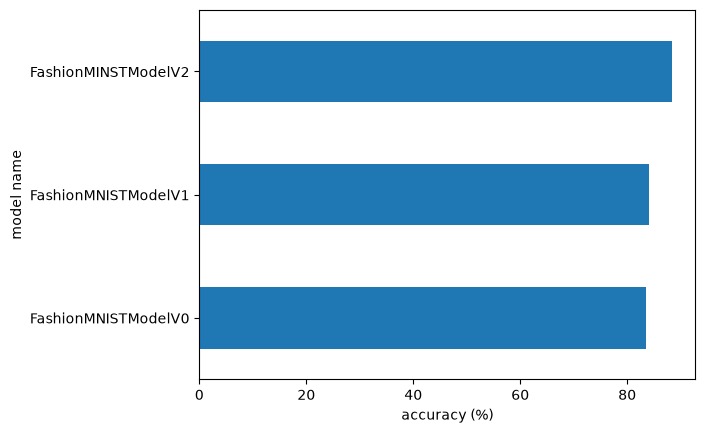

In [ ]:
# Visualize our model results
compare_result.set_index("model_name")["model_accuracy"].plot(kind= "barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model name")

## 9. Make and evaluate random predictions with best model

In [ ]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):

  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      # Prepare the sample (add a batch dimension and pass to target device)
      sample = torch.unsqueeze(sample, dim=0).to(device)

      # Forward pass
      pred_logit = model(sample)

      # Get prediction probability (logit -> pred prob)
      pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

      # Get pred_prob off the GPU for further calculation
      pred_probs.append(pred_prob.cpu())

  # Stack the pred_probs to turn list into a tensor
  return torch.stack(pred_probs)

In [ ]:
import random

test_sample = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
  test_sample.append(sample)
  test_labels.append(label)

  # View the first sample shape
test_sample[0].shape


torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Sneaker')

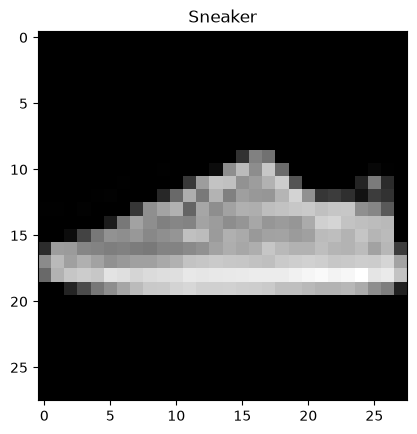

In [ ]:
plt.imshow(test_sample[0].squeeze(), cmap= "grey")
plt.title(class_name[test_labels[0]])

In [ ]:
# Make predictions
pred_probs = make_predictions(model=model_2,
                              data=test_sample)

# View first two predition prob
pred_probs[:2]

tensor([[5.4563e-07, 8.0898e-07, 2.5592e-06, 2.7484e-05, 1.9711e-06, 1.3983e-03,
         1.8027e-07, 9.9725e-01, 6.3099e-04, 6.8427e-04],
        [4.8329e-07, 1.1085e-06, 1.4704e-06, 8.9991e-06, 1.4658e-06, 1.7737e-03,
         2.8026e-07, 9.9648e-01, 1.6151e-04, 1.5677e-03]])

In [ ]:
# Convert pred probs to labels
pred_classes = pred_probs.argmax(dim=1)
pred_classes, test_labels

(tensor([7, 7, 5, 0, 9, 6, 9, 9, 7]), [7, 7, 5, 0, 9, 6, 9, 9, 7])

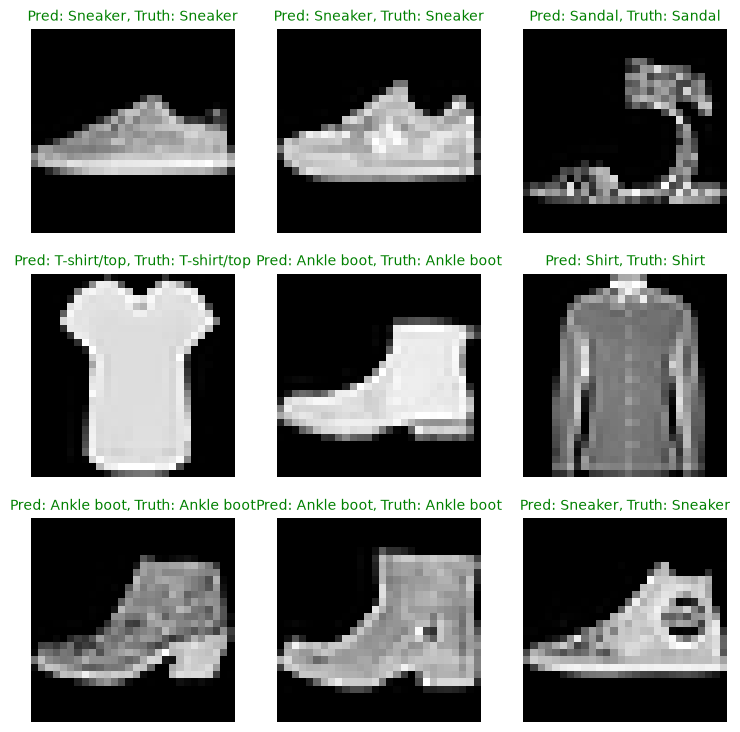

In [ ]:
# Plot predictions
plt.figure(figsize= (9,9))
nrows =3
ncols =3

for i, sample in enumerate(test_sample):
  # Create subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap = "grey")

  # Find the prediction (in text form, e.g "Sandal")
  pred_label = class_name[pred_classes[i]]

  # Get the truth label
  truth_label = class_name[test_labels[i]]

  # Create a title for the plot
  title_text = f"Pred: {pred_label}, Truth: {truth_label}"

  # Check for equality between pred and truth and change color of title text
  if pred_label == truth_label:
    plt.title(title_text, fontsize=10, c ="g")
  else:
    plt.title(title_text, fontsize=10, c ="r")

  plt.axis(False)

## 10. Making a confusion matrix for further prediction probability

A confusion matrixis a fantasitc way of evaluating your classification visually.

1. Make predictions with our trained model on the test dataset
2. Make confusion matrix using `mlxtend.plotting.plot_confusion_matrix()`

In [ ]:
import mlxtend
mlxtend.__version__

'0.25.0'

In [ ]:
# Import tqdm.auto
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc = "Making predictions...."):
    # send the data and targets to target device
    X, y = X.to(device), y.to(device)

    # Do the forward pass
    y_logit = model_2(X)

    # Turn predictions from logits -> pred probs -> labels
    y_pred = torch.softmax(y_logit.squeeze(), dim=0).argmax(dim=1)

    # Put prediction on CPU for evaluation
    y_preds.append(y_pred.cpu())

# Concatenate list of predcition into a tensor
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor, len(y_pred_tensor)

Making predictions....:   0%|          | 0/313 [00:00<?, ?it/s]

(tensor([9, 2, 1,  ..., 8, 1, 2]), 10000)

In [ ]:
# See if required packages are installed, and if not, installed them
try:
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend version should be 0.19 or higher"

except:
  !pip install torchmetrics -U mlxtend
  import torchmetrics, mlxtend

mlxtend version: 0.25.0


In [ ]:
import mlxtend
print(mlxtend.__version__)

0.25.0


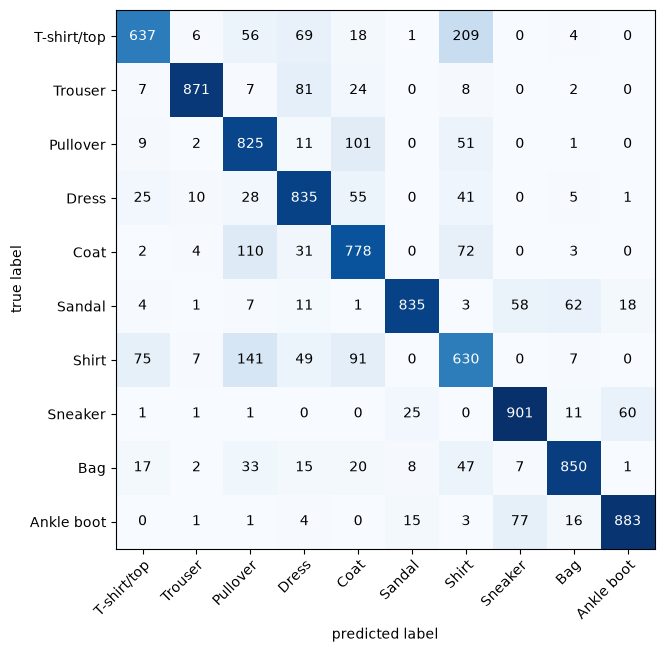

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. steup confusion instance and compare predictions target
confmat= ConfusionMatrix(task="multiclass", num_classes=len(class_name))
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Plot the confusion Matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names = class_name,
    figsize= (10,7)
)

## 11. Save and load best performing model

In [ ]:
from pathlib import Path

# Create model dictory path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents= True,
                 exist_ok= True)

# Create model save path
MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to {MODEL_SAVE_PATH}")
torch.save(obj= model_2.state_dict(),
           f= MODEL_SAVE_PATH)

Saving model to models/03_pytorch_computer_vision_model_2.pth


In [ ]:
torch.manual_seed(42)

loaded_model_2 = FashionMINSTModelV2(input_shape=1,
                                     hidden_units=10,
                                     output_shape=len(class_name))

loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_2.to(device)

FashionMINSTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [ ]:
model_2_results

{'model_name': 'FashionMINSTModelV2',
 'model_loss': 0.3190237879753113,
 'model_accuracy': 88.31869009584665}

In [ ]:
# Evaluate loaded model
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader = test_dataloader,
    loss_fn = loss_fn,
    accuracy_fn = accuracy_fn
)
loaded_model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMINSTModelV2',
 'model_loss': 0.3190237879753113,
 'model_accuracy': 88.31869009584665}